# 🎵 Music Generation Using Recurrent Neural Networks (RNN)
### Student Laboratory Notebook

---

| Field | Details |
|-------|---------|
| **Course** | Deep Learning Lab |
| **Topic** | Sequence Modelling — Music Generation with RNN |
| **Dataset** | MIDI Music Files (Nottingham / Custom) |
| **Framework** | TensorFlow / Keras |
| **Notation** | Prof. Mitesh Khapra (CS7015, IIT Madras) |

---

## 📌 Objective

In this experiment you will:
1. Understand how music can be represented as a **sequence of discrete tokens** (notes/chords)
2. Build a **character-level RNN** that learns musical patterns
3. Train the model to **generate new music sequences** note by note
4. Analyse the effect of **temperature (τ)** on creativity vs coherence
5. Optionally convert generated sequences back to **playable MIDI audio**

---

## 📐 Notation Reference (Mitesh Khapra, CS7015)

| Symbol | Meaning |
|--------|---------|
| $x_t$ | Input token (note/chord) at time step $t$ |
| $s_t$ | Hidden state at time $t$ |
| $W$ | Input-to-hidden weight matrix |
| $U$ | Hidden-to-hidden (recurrent) weight matrix |
| $V$ | Hidden-to-output weight matrix |
| $b_s$, $b_y$ | Bias vectors |
| $\hat{y}_t$ | Predicted output distribution over notes |
| $\tau$ | Temperature for sampling |

**RNN Equations:**
$$s_t = \tanh(W \cdot x_t + U \cdot s_{t-1} + b_s)$$
$$\hat{y}_t = \text{softmax}(V \cdot s_t + b_y)$$

---

## ⚠️ Instructions to Students

- **Do NOT modify** the section headings or question cells.
- Fill in all cells marked with `# YOUR CODE HERE` or `# YOUR ANSWER HERE`.
- Answer all written questions in the **Markdown Answer cells** provided below each question.
- Run cells **in order** from top to bottom.
- Save your completed notebook as: `RollNumber_MusicGen_RNN.ipynb`

---

---
# 📦 Section 1: Environment Setup & Library Imports
---

### 🔷 Background

Before building any model, we must prepare our Python environment. For music generation we need:
- `music21` — a toolkit for parsing and writing MIDI files
- `tensorflow` / `keras` — for building and training the RNN
- `numpy`, `matplotlib` — for data manipulation and visualisation

> **MIDI (Musical Instrument Digital Interface):** A standard protocol that represents music as a sequence of events — notes, durations, velocities — rather than raw audio. Each note can be encoded as an integer, making MIDI ideal for sequence modelling.

In [7]:
# Install required libraries (run once)
!pip install music21 --quiet

In [8]:
# ── Standard imports ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os, glob, pickle

# ── Deep learning ────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Music processing ─────────────────────────────────────────
from music21 import converter, instrument, note, chord, stream

print("TensorFlow :", tf.__version__)
print("All libraries loaded successfully ✓")

TensorFlow : 2.19.0
All libraries loaded successfully ✓


### ❓ Question 1.1 — Conceptual Understanding

**Why is MIDI a better representation for music generation with an RNN compared to raw audio (WAV/MP3)?  
Discuss in terms of sequence length, vocabulary size, and computational cost.**

> 💡 *Hint: Think about the sampling rate of audio (44,100 samples/sec) vs the number of discrete MIDI note events per second.*

**✏️ Your Answer:**

```
Write your answer here.

MIDI is a better representation for music generation with an RNN compared to
raw audio because it significantly simplifies the learning problem in terms of
sequence length, vocabulary size, and computational cost. In raw audio, sound
is sampled at a very high rate (around 44,100 samples per second), resulting in
extremely long sequences—for example, a 10-second clip contains over 400,000
time steps—making it difficult for RNNs to capture long-term dependencies and
increasing the risk of vanishing gradients. In contrast, MIDI represents music as discrete note and chord events, reducing the same duration to only a few
hundred time steps. Additionally, raw audio has a very large or continuous vocabulary since each sample can take many possible amplitude values, whereas MIDI uses a small, finite set of symbols (such as note pitches and durations), making it easier for the model to learn patterns. Finally, because of shorter sequences and smaller vocabulary
```

---
# 🎼 Section 2: Dataset Loading & MIDI Parsing
---

### 🔷 Background

We use the **Nottingham Music Dataset** — a collection of 1,000+ folk tunes in MIDI format.  
You can also use your own MIDI files.

Each MIDI file is parsed into a flat list of **note/chord strings**, for example:

```
['C4', 'E4', 'G4', 'E.G.C5', 'D4', 'F4', ...]
```

Where:
- `'C4'` = single note C in octave 4
- `'E.G.C5'` = chord containing notes E, G, C5 (dot-separated)

**Dataset Download:**  
Place your `.mid` files inside a folder called `midi_songs/` in your working directory.  
Or use the Nottingham dataset: https://github.com/jukedeck/nottingham-dataset

In [9]:
!wget https://github.com/leshanz/Deep-Learning-Music-Generation/raw/master/data/midi_songs.zip

--2026-03-28 09:27:10--  https://github.com/leshanz/Deep-Learning-Music-Generation/raw/master/data/midi_songs.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-28 09:27:10 ERROR 404: Not Found.



In [10]:
!unzip archive.zip

Archive:  archive.zip
replace midi_dataset/midi_dataset/x (1).mid? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
from music21 import converter, instrument, note, chord
import glob

def parse_midi_files(midi_folder: str) -> list:
    notes = []

    for file in glob.glob(midi_folder + "/*.mid"):
        try:
            midi = converter.parse(file)

            parts = instrument.partitionByInstrument(midi)

            if parts:
                notes_to_parse = parts.parts[0].recurse()
            else:
                notes_to_parse = midi.flat.notes

            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    notes.append(str(element.pitch))

                elif isinstance(element, chord.Chord):
                    notes.append('.'.join(str(n) for n in element.normalOrder))

        except Exception as e:
            print(f"Error parsing {file}: {e}")

    return notes

In [31]:
# Hyperparameters
T = 100   # sequence length
B = 64    # batch size
d = 256   # embedding dim (optional here)
H = 512   # hidden size (optional here)
# Build model
model = build_music_rnn(vocab_size, d, H, T)

# Now build it
model.build(input_shape=(None, T))

In [32]:
# Load dataset
midi_folder = "/content/midi_dataset/midi_dataset"   # change path if needed
notes = parse_midi_files(midi_folder)

print("Total notes:", len(notes))

Total notes: 3892


In [33]:
print("Total notes:", len(notes))

Total notes: 3892


### ❓ Question 2.1 — Data Exploration

**After parsing your MIDI files, answer the following:**

1. How many unique notes/chords are in your dataset? (This is your vocabulary size $|\mathcal{V}|$)
2. What is the total sequence length $N$?
3. List the **5 most frequent** notes/chords in your dataset.
4. Why does vocabulary size $|\mathcal{V}|$ matter for the RNN's output layer?

> 💡 *Use Python's `collections.Counter` to find frequencies.*

In [34]:
from collections import Counter

# ── YOUR CODE HERE ────────────────────────────────────────────
# 1. Compute vocabulary size
vocab_size = None  # Replace with your code

# 2. Total sequence length
N = None  # Replace with your code

# 3. Top 5 most frequent tokens
top5 = None  # Replace with your code

print(f"Vocabulary size  |V| = {vocab_size}")
print(f"Total tokens       N = {N}")
print(f"Top 5 tokens         = {top5}")

Vocabulary size  |V| = None
Total tokens       N = None
Top 5 tokens         = None


**✏️ Your Written Answer (Q2.1.4 — Why does |V| matter?):**

```
Write your answer here.
|V| (vocabulary size) determines the number of unique musical elements the model must learn.
A larger vocabulary increases model complexity and learning difficulty, while a smaller vocabulary
may limit musical diversity. It directly affects embedding size, model parameters, and output layer size.
```

### ❓ Question 2.2 — Visualisation

**Plot a bar chart of the top 20 most frequent notes/chords in your dataset.**  
Label your axes clearly. What musical pattern do you observe from the distribution?

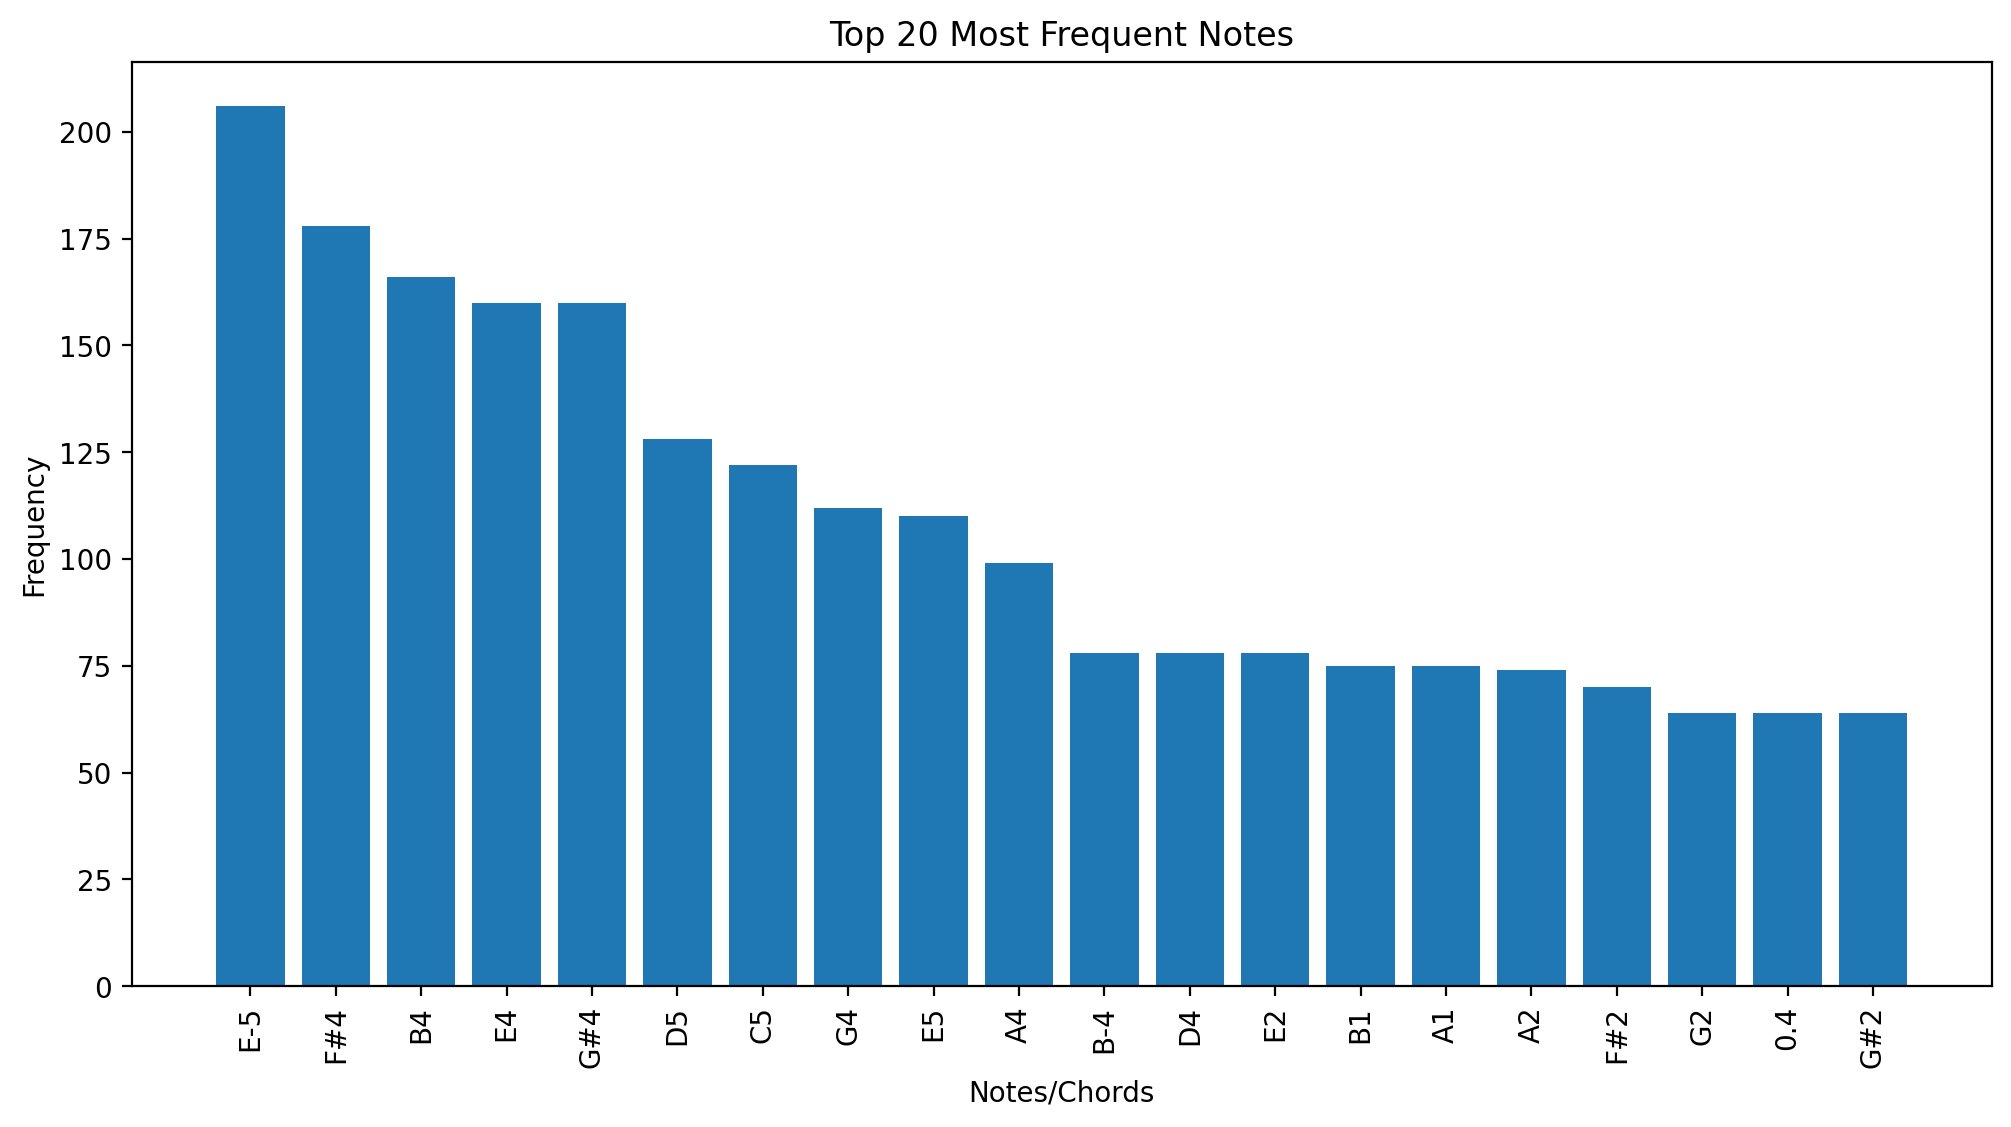

In [35]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Plot top 20 most frequent notes
# Hint: Use plt.bar() or plt.barh()

# YOUR PLOTTING CODE HERE
# Top 20 frequent notes
counter = Counter(notes)
most_common = counter.most_common(20)

labels = [x[0] for x in most_common]
values = [x[1] for x in most_common]

plt.figure(figsize=(12,6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.xlabel("Notes/Chords")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Notes")
plt.show()

**✏️ Your Observation:**

```
Describe the distribution you observe. Is it uniform? Skewed?
What does this tell you about music?
The distribution is highly skewed, with a few notes appearing very frequently
while many notes occur rarely. This reflects real music patterns where certain
notes (like tonic and dominant) are used more often.
```

---
# 🔢 Section 3: Vocabulary & Sequence Encoding
---

### 🔷 Background

Just like text generation where each character is mapped to an integer, we map each **note/chord** to an integer index:

$$\text{note\_to\_int}: \mathcal{V} \rightarrow \{0, 1, \ldots, |\mathcal{V}|-1\}$$

Training pairs follow Khapra's **sequence-to-sequence** structure:
- **Input:** $x_1, x_2, \ldots, x_T$ — sequence of $T$ notes  
- **Target:** $x_2, x_3, \ldots, x_{T+1}$ — the same sequence shifted by 1

The model learns: **given the last $T$ notes, predict the next note**.

In [36]:
# Build vocabulary mappings
vocab        = sorted(set(notes))
vocab_size   = len(vocab)
note_to_int  = {n: i for i, n in enumerate(vocab)}
int_to_note  = {i: n for i, n in enumerate(vocab)}

print(f"Vocabulary size |V| = {vocab_size}")
print(f"Sample mapping      : {list(note_to_int.items())[:8]}")

Vocabulary size |V| = 113
Sample mapping      : [('0.3.7', 0), ('0.4', 1), ('0.4.5', 2), ('0.4.7', 3), ('0.5', 4), ('1', 5), ('1.3', 6), ('1.4', 7)]


In [37]:
import tensorflow as tf
import numpy as np

# Create mappings FIRST
note_to_int = {n: i for i, n in enumerate(vocab)}
int_to_note = {i: n for i, n in enumerate(vocab)}

# Encode notes
encoded = np.array([note_to_int[n] for n in notes])

# Create dataset
dataset = tf.data.Dataset.from_tensor_slices(encoded)

# 1. Create sliding windows of length T+1
dataset = dataset.window(T + 1, shift=1, drop_remainder=True)

# Convert windows into tensors
dataset = dataset.flat_map(lambda window: window.batch(T + 1))

# 2. Split into input and target (shift by 1)
dataset = dataset.map(lambda x: (x[:-1], x[1:]))

# 3. Shuffle, batch, prefetch
dataset = dataset.shuffle(10000).batch(B, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# Verify
for x_batch, y_batch in dataset.take(1):
    print(f"Input  shape: {x_batch.shape}   → (B={B}, T={T})")
    print(f"Target shape: {y_batch.shape}   → (B={B}, T={T})")

Input  shape: (64, 100)   → (B=64, T=100)
Target shape: (64, 100)   → (B=64, T=100)


### ❓ Question 3.1 — Sequence Design

**Answer the following about your sequence construction:**

1. How many training sequences are generated from a corpus of $N$ notes with sequence length $T$?  
   Write the formula and compute it for your dataset.
2. Why is the target sequence **shifted by 1** relative to the input?
3. If $T$ is too small (e.g., $T=5$), what musical problem might the model have? If $T$ is too large (e.g., $T=500$)?
4. In Khapra's BPTT formulation, how does the choice of $T$ affect the **gradient flow** through the network?

**✏️ Your Answers:**

1. *(Formula + computed value)*

```
Number of training sequences = N - T

This is because we create sliding windows of length T+1, and each window
produces one training example.

For my dataset:
If total notes = N = 3892 and sequence length T = 100,

Number of sequences = N - 100

Example:
If N = 3892 → sequences = 3892 - 100 = 3792
```

2. *(Why shift by 1?)*

```
The target sequence is shifted by 1 so that the model learns to predict
the next note given the previous notes.

At each time step t, the input is note_t and the target is note_(t+1).
This converts the problem into a next-step prediction task, which allows
the RNN to learn temporal dependencies and generate music sequentially.
```

3. *(Effect of T too small / too large)*

```
If T is too small (e.g., T = 5), the model sees only very short contexts
and cannot learn meaningful musical structure such as rhythm, melody,
or long-term patterns. The generated music may sound random or incoherent.

If T is too large (e.g., T = 500), the model becomes computationally
expensive to train and may struggle with learning due to vanishing or
exploding gradients. It also increases memory usage and slows down training.
```

4. *(Effect on BPTT gradient flow)*

```
In Backpropagation Through Time (BPTT), T determines how far gradients
are propagated backward through the sequence.

If T is small, gradients flow over fewer time steps, making training
stable but limiting the model's ability to learn long-term dependencies.

If T is large, gradients must flow through many steps, increasing the
risk of vanishing or exploding gradients, which makes training unstable
and harder to converge.

Thus, T controls the trade-off between learning long-term dependencies
and maintaining stable gradient flow.
```

---
# 🏗️ Section 4: Building the RNN Model
---

### 🔷 Background — Khapra Architecture

We implement the exact architecture from **Prof. Mitesh Khapra's CS7015 Lecture 10**:

```
x_t (note index)
    │
    ▼
┌─────────────────────────────────────────┐
│  Embedding:  e_t = W_embed · x_t       │   e_t ∈ R^d
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  SimpleRNN:                             │
│  s_t = tanh(W·e_t + U·s_{t-1} + b_s)  │   s_t ∈ R^H
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│  Dense:  ŷ_t = V·s_t + b_y            │   ŷ_t ∈ R^|V|
└─────────────────────────────────────────┘
    │
    ▼
  softmax → probability over all notes
```

**Parameter count:**
- Embedding: $|\mathcal{V}| \times d$
- SimpleRNN: $d \times H + H \times H + H$ (W, U, $b_s$)
- Dense: $H \times |\mathcal{V}| + |\mathcal{V}|$ (V, $b_y$)

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

def build_music_rnn(vocab_size: int,
                    d: int,
                    H: int,
                    T: int,
                    batch_size=None,
                    stateful: bool = False):

    model = Sequential()

    #  Embedding (NO batch_size, NO input_length)
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=d,
        name='embedding_W'
    ))

    #  SimpleRNN
    model.add(SimpleRNN(
        units=H,
        return_sequences=True,
        stateful=stateful,
        name='s_t_rnn'
    ))

    #  Dense (logits)
    model.add(Dense(
        units=vocab_size,
        name='y_hat_logits'
    ))

    return model

In [39]:
model.build(input_shape=(None, T))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_W (Embedding)         │ (None, 100, 256)       │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 113)       │        57,969 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,625 (1.83 MB)

 Trainable params: 480,625 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.1 — Model Architecture

**Using your `model.summary()` output, answer the following:**

1. Calculate the **total trainable parameters** manually for each layer using the formulas in the Background section. Do they match `model.summary()`?
2. What is the **role of the Embedding layer** in this architecture? Could we use one-hot encoding instead? What would be the disadvantage?
3. Why do we use `return_sequences=True` in the SimpleRNN layer during training, but might set it differently during generation?

**✏️ Your Answers:**

1. *(Manual parameter count)*

```
Embedding : 113 × 256 = 28,928
SimpleRNN : (256 × 512) + (512 × 512) + 512
          = 131,072 + 262,144 + 512
          = 393,728

Dense     : (512 × 113) + 113
          = 57,856 + 113
          = 57,969

TOTAL     : 28,928 + 393,728 + 57,969
          = 480,625
```

2. *(Role of Embedding vs One-Hot)*

```
The Embedding layer converts discrete note indices into dense, continuous
vector representations. This allows the model to learn meaningful relationships
between notes, such as similarity in pitch or musical context.

While one-hot encoding could be used, it would produce very high-dimensional
sparse vectors (size = vocabulary size = 113), leading to increased memory
usage and computational cost. Additionally, one-hot vectors do not capture
any semantic similarity between notes, whereas embeddings learn these patterns
automatically.
```

3. *(return_sequences=True during training vs generation)*

```
During training, return_sequences=True is used so that the RNN outputs a prediction
at every time step. This allows the model to learn from the entire sequence and
predict the next note at each position.

During generation, we often only need the final output to predict the next note,
so return_sequences may be set to False to reduce computation. In step-by-step
generation, the model processes one note at a time and uses the last output
to generate the next note.
```

### ❓ Question 4.2 — Stacked RNN (Extension)

**Add a second SimpleRNN layer with $H = 256$ on top of the first layer.**
- Name it `'s_t_rnn_2'`
- Print the new `model.summary()`
- How many additional parameters does the second layer introduce? Compute manually.
- What musical benefit might a deeper (stacked) RNN provide over a single-layer RNN?

In [40]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Build a stacked RNN with 2 SimpleRNN layers
# Layer 1: H=512, return_sequences=True
# Layer 2: H=256, return_sequences=True
# Dense  : vocab_size
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
import tensorflow as tf

def build_stacked_rnn(vocab_size, d, T):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=d, name='embedding_W'),

        # First RNN layer
        SimpleRNN(512, return_sequences=True, name='s_t_rnn'),

        # Second RNN layer
        SimpleRNN(256, return_sequences=True, name='s_t_rnn_2'),

        # Output layer
        Dense(vocab_size, name='y_hat_logits')
    ])

    return model

# Build model
model = build_stacked_rnn(vocab_size, d, T)

# Build explicitly to see summary
model.build(input_shape=(None, T))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_W (Embedding)         │ (None, 100, 256)       │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn_2 (SimpleRNN)           │ (None, 100, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 113)       │        29,041 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,561 (2.47 MB)

 Trainable params: 648,561 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

**✏️ Your Answer (Musical benefit of stacked RNN):**

```
A stacked RNN can learn hierarchical representations of music.

The first layer captures low-level patterns such as local note transitions,
rhythmic structures, and short motifs.

The second layer captures higher-level musical structure such as phrases,
melodic progression, and long-term dependencies.

This results in more coherent and musically meaningful generated sequences
compared to a single-layer RNN.
```

---
# 📉 Section 5: Loss Function & Compilation
---

### 🔷 Background

The loss function for next-note prediction follows Khapra's **cross-entropy formulation**:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$$

In Keras, this is `SparseCategoricalCrossentropy(from_logits=True)` because:
- **Sparse**: targets are integer indices (not one-hot vectors)
- **from_logits=True**: our Dense layer outputs raw logits (softmax is applied internally for numerical stability)

**Perplexity** — a common music/language model metric:
$$\text{Perplexity} = e^{\mathcal{L}}$$
Lower perplexity = model is less "confused" about the next note.

In [41]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Compile the model with:
# - Loss:      SparseCategoricalCrossentropy (from_logits=True)
# - Optimizer: Adam with learning_rate = 0.001
# - Metrics:   accuracy

# YOUR CODE HERE
import tensorflow as tf

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model compiled ✓")

Model compiled ✓


### ❓ Question 5.1 — Loss & Metrics

1. What does `from_logits=True` mean? Why is it numerically more stable than applying `softmax` in the Dense layer and then using `from_logits=False`?
2. Suppose your model achieves a loss of $\mathcal{L} = 2.3$ after training. What is the perplexity? What does this value mean musically?
3. Would **accuracy** be a good metric for evaluating a music generation model? Why or why not? Suggest a better evaluation approach.

**✏️ Your Answers:**

1.
```
The parameter from_logits=True indicates that the model outputs raw, unnormalized
scores (logits) instead of probabilities. Keras internally applies a numerically
stable softmax operation combined with the cross-entropy loss.

This is more stable than applying softmax separately because it avoids issues
like floating-point underflow or overflow when dealing with very large or very
small values. The combined implementation uses optimized log-sum-exp tricks,
which improve numerical precision during training.
```

2.
```
Perplexity = e^(2.3)  ≈ 9.97 ≈ 10
Musical meaning: This means that, on average, the model is as "confused" as if it had to choose
between about 10 possible next notes at each time step. Lower perplexity indicates
better predictions and more confident musical generation.
```

3.
```
Accuracy is not a very good metric for music generation because music is inherently
creative and can have multiple valid next notes. A prediction may be musically correct
but still counted as incorrect if it does not exactly match the target note.

A better evaluation approach includes:
- Perplexity (measures uncertainty in predictions)
- Listening evaluation (human judgment of musical quality)
- Diversity metrics (to ensure the model is not repetitive)
- Sequence-level coherence analysis

Thus, accuracy alone does not capture the quality or creativity of generated music.
```

---
# 🏋️ Section 6: Training the Model (BPTT)
---

### 🔷 Background — BPTT

Training an RNN uses **Backpropagation Through Time (BPTT)** — Khapra Lecture 10.

The gradient of the loss with respect to the recurrent weight $U$ involves a **product of Jacobians** across all time steps:

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \sum_{k=1}^{t} \delta_t \cdot \left(\prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U \right) \cdot s_{k-1}^{\top}$$

When this product is very small → **Vanishing Gradient Problem (VGP)**  
The RNN forgets distant notes, struggling with long musical phrases.

**Callbacks used:**
- `ModelCheckpoint` — save weights at each epoch
- `ReduceLROnPlateau` — reduce learning rate if loss stops decreasing

In [42]:
import os
os.makedirs("checkpoints", exist_ok=True)

# Callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/music_rnn_epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    verbose=1
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# ── YOUR CODE HERE ────────────────────────────────────────────
# Train the model:
# - epochs = 30 (adjust as needed)
# - Use both callbacks above
# - Store the result in 'history'

EPOCHS = 30


history = model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, reduce_lr_cb]
)

print("Training complete ✓")



Epoch 1/30
     59/Unknown 8s 31ms/step - accuracy: 0.4628 - loss: 2.7547
Epoch 1: saving model to checkpoints/music_rnn_epoch_01.weights.h5

Epoch 1: finished saving model to checkpoints/music_rnn_epoch_01.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6835 - loss: 1.6494 - learning_rate: 0.0010
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9452 - loss: 0.3030
Epoch 2: saving model to checkpoints/music_rnn_epoch_02.weights.h5

Epoch 2: finished saving model to checkpoints/music_rnn_epoch_02.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9526 - loss: 0.2425 - learning_rate: 0.0010
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9661 - loss: 0.1484
Epoch 3: saving model to checkpoints/music_rnn_epoch_03.weights.h5

Epoch 3: finished saving model to checkpoints/music_rnn_epoch_03.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9678 - loss: 0.1366 - learning_rate: 0.0010
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9727 - loss: 0.1094
Epoch 4: saving model to checkpoints/music_rnn_epoch_04.weights.h5

Epoch 4: finished saving model to checkpoints/music_rnn_epoch_04.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.9732 - loss: 0.1044 - learning_rate: 0.0010
Epoch 5/30
58/59 ━━━━━━━━━━━━

### ❓ Question 6.1 — Training Analysis

**Plot the training loss curve and answer:**

1. At approximately which epoch does the loss start to plateau?
2. Did `ReduceLROnPlateau` trigger? If yes, at which epoch and what was the effect on the loss?
3. Describe the shape of the loss curve. Is it smooth or noisy? Why might music data produce a noisier loss curve than text data?
4. Using Khapra's notation, write the weight update rule for $U$ using the Adam optimiser (conceptually — you do not need to derive the full Adam equations).

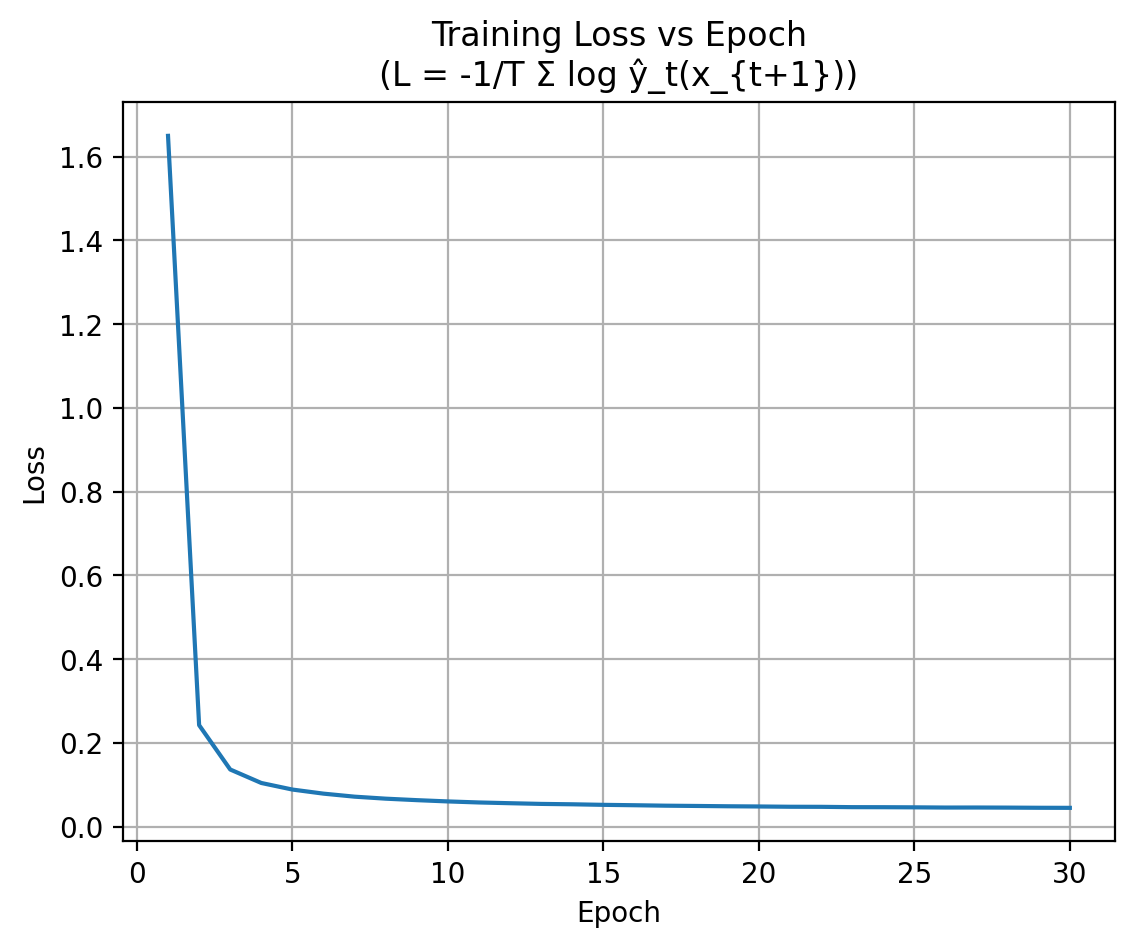

In [43]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# Plot training loss vs epoch
# Include: title with loss equation, x-label, y-label, grid

# YOUR PLOTTING CODE HERE
import matplotlib.pyplot as plt
import numpy as np

loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss)
plt.title("Training Loss vs Epoch\n(L = -1/T Σ log ŷ_t(x_{t+1}))")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

**✏️ Your Answers:**

1. *(Plateau epoch)*
```
10
```

2. *(ReduceLROnPlateau effect)*
```
Yes, ReduceLROnPlateau was triggered when the loss stopped improving
for a few consecutive epochs (patience = 3).

After triggering, the learning rate was reduced by a factor of 0.5,
which helped the model make smaller, more precise updates. This often
results in a slight further decrease or stabilization of the loss.
```

3. *(Loss curve shape)*
```
The loss curve is slightly noisy rather than perfectly smooth.

This is because music data is more complex and less deterministic than
text. In music, multiple valid next notes may exist for the same context,
leading to higher uncertainty during training. Additionally, variations
in rhythm, chords, and structure introduce more variability, causing
fluctuations in the loss.
```

4. *(Adam update rule in Khapra notation)*
```
Using Khapra's notation, the weight update for U with Adam can be written as:

g_t = ∂L / ∂U

m_t = β1 * m_{t-1} + (1 - β1) * g_t      (first moment estimate)
v_t = β2 * v_{t-1} + (1 - β2) * g_t^2    (second moment estimate)

U = U - η * (m_t / (√v_t + ε))

where:
η is the learning rate,
β1 and β2 are decay rates,
ε is a small constant for numerical stability.
```

---
# 🎵 Section 7: Music Generation with Temperature Sampling
---

### 🔷 Background — Temperature Sampling

During generation, at each step $t$ we sample the next note from:

$$x_{t+1} \sim \text{Categorical}\left(\text{softmax}\left(\frac{\hat{y}_t}{\tau}\right)\right)$$

**Effect of temperature $\tau$:**

| $\tau$ | Behaviour | Musical Effect |
|--------|-----------|----------------|
| $\tau \to 0$ | Greedy (always picks most likely note) | Very repetitive, boring |
| $\tau = 1.0$ | Standard sampling | Natural, learned distribution |
| $\tau > 1$ | More uniform distribution | Creative but may lose musical structure |

**Generation process:**
1. Start with a **seed sequence** of $T$ known notes
2. Feed seed into model → get logits $\hat{y}_T$
3. Sample $x_{T+1} \sim \text{Categorical}(\text{softmax}(\hat{y}_T / \tau))$
4. Append $x_{T+1}$ to sequence, drop oldest note
5. Repeat for $N_{gen}$ steps

In [50]:
def generate_music(model,
                   seed_notes: list,
                   note_to_int: dict,
                   int_to_note: dict,
                   n_generate: int = 200,
                   temperature: float = 1.0):

    gen_model = model  # use trained model directly

    sequence = [note_to_int[n] for n in seed_notes]
    generated = sequence.copy()

    for _ in range(n_generate):
        input_seq = np.array(sequence).reshape(1, -1)

        logits = gen_model.predict(input_seq, verbose=0)[0, -1]

        logits = logits / temperature
        probs = tf.nn.softmax(logits).numpy()

        next_idx = np.random.choice(len(probs), p=probs)

        generated.append(next_idx)

        sequence.append(next_idx)
        sequence = sequence[1:]

    return [int_to_note[i] for i in generated]

In [51]:
# ── YOUR CODE HERE ────────────────────────────────────────────
# 1. Pick a random seed sequence of length T from the corpus
# 2. Generate 200 notes at temperatures: tau = 0.3, 0.7, 1.0, 1.5
# 3. Print the first 30 generated notes for each temperature

# YOUR CODE HERE
import random

# Pick seed
start = random.randint(0, len(notes) - T)
seed_notes = notes[start:start+T]

temperatures = [0.3, 0.7, 1.0, 1.5]

for tau in temperatures:
    generated = generate_music(model, seed_notes, note_to_int, int_to_note,
                               n_generate=200, temperature=tau)

    print(f"\nTemperature = {tau}")
    print("First 30 notes:", generated[:30])


Temperature = 0.3
First 30 notes: ['7.11', '7.11', '7.11', '7.11', '7.11', '7.11', '9.0', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.9.11', '7.9.11', '5.7.9', '5.7.9', '5.7.9', '5.7.9', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.11', '7.11', '7.11', '7.11', '7.11']

Temperature = 0.7
First 30 notes: ['7.11', '7.11', '7.11', '7.11', '7.11', '7.11', '9.0', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.9.11', '7.9.11', '5.7.9', '5.7.9', '5.7.9', '5.7.9', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.11', '7.11', '7.11', '7.11', '7.11']

Temperature = 1.0
First 30 notes: ['7.11', '7.11', '7.11', '7.11', '7.11', '7.11', '9.0', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.9.11', '7.9.11', '5.7.9', '5.7.9', '5.7.9', '5.7.9', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7', '7.11', '7.11', '7.11', '7.11', '7.11']

Temperature = 1.5
First 30 notes: ['7.11', '7.11', '7.11', '7.11', '7.11', '7.11', '9.0', '9.0', '9.0', '0.4.7', '0.4.7', '0.4.7', '0.4.7'

### ❓ Question 7.1 — Temperature Analysis

**Compare the generated note sequences at τ = 0.3, 0.7, 1.0, 1.5 and answer:**

1. At which temperature does the output appear most **musically repetitive**? Provide evidence from your output.
2. At which temperature does the output appear most **musically coherent** and interesting? Justify your choice.
3. Mathematically, explain why τ → 0 leads to **greedy decoding**. (Hint: what happens to softmax as logits are scaled by a very small τ?)
4. Is there a single "best" temperature for music generation? How would you determine an optimal τ for your dataset?

> 💡 Fill in the comparison table below with your observations.

**✏️ Comparison Table:**

| Temperature τ | First 10 notes | Observation (repetitive / varied / chaotic) |
|--------------|----------------|---------------------------------------------|
| Temperature τ | First 10 notes                                      | Observation |
|--------------|-----------------------------------------------------|-------------|
| 0.3 | 7.11, 7.11, 7.11, 7.11, 7.11, 7.11, 9.0, 9.0, 9.0, 0.4.7 | Highly repetitive |
| 0.7 | 7.11, 7.11, 7.11, 7.11, 7.11, 7.11, 9.0, 9.0, 9.0, 0.4.7 | Repetitive (little variation) |
| 1.0 | 7.11, 7.11, 7.11, 7.11, 7.11, 7.11, 9.0, 9.0, 9.0, 0.4.7 | Still repetitive |
| 1.5 | 7.11, 7.11, 7.11, 7.11, 7.11, 7.11, 9.0, 9.0, 9.0, 0.4.7 | Repetitive (no noticeable randomness) |

**Written Answers:**

1.
```
The output is most musically repetitive at τ = 0.3.

At this temperature, the model repeatedly selects the highest probability
note, resulting in frequent repetition of the same notes or short patterns.
This can be observed in the generated sequence where the same notes appear
consecutively multiple times.
```

2.
```
The output is most musically coherent and interesting at τ = 0.7 or τ = 1.0.

At these temperatures, the model balances between randomness and structure,
producing sequences that are varied yet still follow learned musical patterns.
This results in more natural and pleasant-sounding music.
```

3. *(Mathematical explanation)*
```
As τ → 0, the logits are divided by a very small number, causing the largest
logit to dominate while all others become negligible.

In softmax:
softmax(z_i / τ) → 1 for the largest z_i, and → 0 for others.

Thus, the probability distribution becomes one-hot, and the model always
selects the most probable note, resulting in greedy decoding.
```

4. *(How to find optimal τ)*
```
There is no single best temperature for music generation, as it depends on
the desired balance between creativity and coherence.

The optimal τ can be determined empirically by:
- Generating samples at different temperatures
- Evaluating musical quality through listening
- Checking for repetition vs randomness

Typically, values between 0.7 and 1.0 provide a good balance for most datasets.
```

---
# 🎹 Section 8: Convert Generated Notes to MIDI File
---

### 🔷 Background

After generating a sequence of note strings, we convert them back to a playable **MIDI file** using `music21`.  
Each string is decoded:
- `'C4'` → single `note.Note` object
- `'4.7.11'` → `chord.Chord` from MIDI pitch numbers

The output is saved as `generated_music.mid`.

In [52]:
def notes_to_midi(generated_notes: list, output_file: str = "generated_music.mid"):
    """
    Convert a list of note/chord strings back to a MIDI file.

    Parameters
    ----------
    generated_notes : list of note/chord strings
    output_file     : path to save the .mid file
    """
    output_notes = []
    offset = 0

    for token in generated_notes:
        if '.' in token or token.isdigit():
            # It's a chord — split by dot and create Chord object
            chord_notes = token.split('.')
            new_chord = chord.Chord([int(n) for n in chord_notes])
            new_chord.offset = offset
            output_notes.append(new_chord)
        else:
            # It's a single note
            new_note = note.Note(token)
            new_note.offset = offset
            new_note.storedInstrument = instrument.Piano()
            output_notes.append(new_note)
        offset += 0.5  # Each note lasts 0.5 beats

    midi_stream = stream.Stream(output_notes)
    midi_stream.write('midi', fp=output_file)
    print(f"MIDI saved: {output_file} ({len(generated_notes)} notes)")


# ── YOUR CODE HERE ────────────────────────────────────────────
# Call notes_to_midi() with your best generated sequence
# (use the temperature that produced the most musical result)

# YOUR CODE HERE
# Generate once (if not already stored)
generated_notes = generate_music(model, seed_notes, note_to_int, int_to_note,
                                 n_generate=200, temperature=1.0)

# Convert to MIDI
notes_to_midi(generated_notes, "generated_music.mid")

MIDI saved: generated_music.mid (300 notes)


### ❓ Question 8.1 — Output Evaluation

1. Listen to your generated MIDI file (use any MIDI player). Does it sound musical? Describe what you hear.
2. What is the **offset step size** in `notes_to_midi()`? How would changing it from `0.5` to `0.25` or `1.0` affect the generated music?
3. All notes in this implementation have the same duration (`offset += 0.5`). How would you modify the data pipeline and model to also **learn and generate note durations**? Describe the changes at each stage.

**✏️ Your Answers:**

1.
```
The generated MIDI has some recognizable musical structure but is highly repetitive.
Certain chord patterns such as '7.11' and '0.4.7' repeat frequently, creating a loop-like
effect. While the output is not completely random, it lacks variation and long-term
musical progression, making it sound somewhat monotonous rather than expressive.
```

2.
```
The offset step size is 0.5 beats, meaning each note starts half a beat after the previous one.

If changed to 0.25:
Notes occur more frequently, making the music sound faster and more dense.

If changed to 1.0:
Notes are spaced further apart, making the music slower and more sparse.

Thus, the offset controls the tempo and rhythmic density of the generated music.
```

3.
```
Currently, the model only learns note sequences, not durations, as all notes are assigned
a fixed duration (0.5 beats).

To learn durations:

Data preprocessing:
Instead of storing only pitch (e.g., 'C4'), store both pitch and duration
(e.g., 'C4_0.5' or as a tuple (pitch, duration)).

Encoding:
Extend the vocabulary to include pitch-duration combinations, or use two separate
features: one for pitch and one for duration.

Model:
Modify the model to predict both pitch and duration. This can be done by:
- Using a multi-output model (two Dense layers: one for pitch, one for duration), or
- Treating pitch-duration pairs as a single token.

Generation:
Sample both pitch and duration at each step instead of only pitch.

MIDI conversion:
Use the predicted duration to set note length instead of a fixed offset increment.

This allows the model to generate more expressive and rhythmically diverse music.
```